# Question & Background Information

This dataset comes from Kaggle and is compiled as part of the Abracadabra project. It contains approximately 550,000 Spotify tracks with lyrics, emotion labels, and audio features per song including tempo, energy, danceability, acousticness, and more. The dataset has 39 columns and utilizes a wide range of songs.

**Our central question is: how well audio features predict if a song is good for studying/doing work?** This is important because platforms like Spotify heavily rely on audio characteristics, such as tempo, key, loudness, and danceability, to suggest and curate playlist recommendations for users based on their mood and listening habits.

If audio features can reliably predict whether a song will improve a student's productivity and work performance, Spotify would greatly benefit from the success. This success would lead to ultimately more subscriptions and listening hours. Studies have shown that when a student listens to 'good study music' their productivity will increase compared to distracting and even no music at all. For example, slower tempo, and low danceability can put a student in the locked in zone. When in contrast fast moving songs that are 'Good for Party' would lead a student to distraction and poor work production. By identifying these patterns, recommendation algorithms can generate playlists for users such as 'study mode', 'in the library', or 'academic weapon!' with greater precision.

At the same time, personal experience does play an important role in music and how individuals utilize songs in different settings. This may not be captured in the data. This means that while audio features may provide useful signals about songs, they likely offer an incomplete picture of how much productivity a song can foster.

We will explore this question of if audio features can predict if a song is good for studying or not and what features lead to this decision to find if we can create a model to accurately predict this binary classification. We want to see if data alone, not accounting for personal experience, can classify songs correctly.

We will approach this with two models:
1. **Logistic Regression**: supervised exploration of whether songs can be classified right or left of the good for study threshold using features such as tempo, instrumentalness, and other numeric values
2. **Decision Tree**: a formal classification model to predict if a song is good for studying and will promote productivity

# Imports and Load Data 

In [1]:
#load libraries
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import graphviz
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score, accuracy_score, precision_score, ConfusionMatrixDisplay 
from sklearn.ensemble import RandomForestClassifier

/workspaces/ML_Final_Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the dataset from Kaggle
# 1. This handles the login and download
# It will prompt you for your username and key from the json file
path = kagglehub.dataset_download("devdope/900k-spotify")

# 2. Load the specific CSV from that path
# The file in this dataset is named 'spotify_dataset.csv'
df = pd.read_csv(f"{path}/spotify_dataset.csv")

print(df.head())


  Artist(s)                       song  \
0       !!!  Even When the Waters Cold   
1       !!!         One Girl / One Boy   
2       !!!          Pardon My Freedom   
3       !!!                        Ooo   
4       !!!                 Freedom 15   

                                                text Length  emotion    Genre  \
0  Friends told her she was better off at the bot...  03:47  sadness  hip hop   
1  Well I heard it, playing soft From a drunken b...  04:03  sadness  hip hop   
2  Oh my god, did I just say that out loud? Shoul...  05:51      joy  hip hop   
3  [Verse 1] Remember when I called you on the te...  03:44      joy  hip hop   
4  [Verse 1] Calling me like I got something to s...  06:00      joy  hip hop   

           Album       Release Date     Key  Tempo  ...  \
0       Thr!!!er    29th April 2013   D min    105  ...   
1       Thr!!!er    29th April 2013  A# min    117  ...   
2  Louden Up Now      8th June 2004   A Maj    121  ...   
3          As If  16th O

# EDA

In [3]:
# explore the dataset's columns, non-null count, and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 551443 entries, 0 to 551442
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Artist(s)                       551443 non-null  str    
 1   song                            551427 non-null  str    
 2   text                            551443 non-null  str    
 3   Length                          551443 non-null  str    
 4   emotion                         551443 non-null  str    
 5   Genre                           551443 non-null  str    
 6   Album                           551391 non-null  str    
 7   Release Date                    551443 non-null  str    
 8   Key                             551443 non-null  str    
 9   Tempo                           551443 non-null  int64  
 10  Loudness (db)                   551443 non-null  str    
 11  Time signature                  551435 non-null  str    
 12  Explicit                   

In [4]:
# get a summary statistics of the dataset
df.describe()

,Tempo,Popularity,Energy,Danceability,Positiveness,Speechiness,Liveness,Acousticness,Instrumentalness,Good for Party,...,Good for Relaxation/Meditation,Good for Exercise,Good for Running,Good for Yoga/Stretching,Good for Driving,Good for Social Gatherings,Good for Morning Routine,Similarity Score 1,Similarity Score 2,Similarity Score 3
count,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,...,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000
mean,120.513567,32.258106,62.661874,59.195460,47.738330,11.663980,19.655658,25.748436,7.152255,0.061809,...,0.030772,0.187334,0.053842,0.021484,0.057797,0.012253,0.066215,0.984107,0.979013,0.975938
std,29.185533,18.033931,22.399159,17.511007,24.159671,12.342389,16.274817,29.343731,20.589200,0.240808,...,0.172700,0.390180,0.225707,0.144990,0.233360,0.110014,0.248658,0.013559,0.015438,0.016512
min,31.000000,0.000000,0.000000,6.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002656,0.002647,0.002647
25%,97.000000,20.000000,48.000000,47.000000,28.000000,4.000000,10.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.977433,0.971582,0.967926
50%,120.000000,30.000000,65.000000,60.000000,47.000000,6.000000,13.000000,12.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.985926,0.980971,0.978078
75%,140.000000,43.000000,80.000000,72.000000,66.000000,15.000000,25.000000,43.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.993567,0.988592,0.986079
max,200.000000,100.000000,100.000000,99.000000,100.000000,97.000000,100.000000,100.000000,100.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# print column names
print(df.columns) 


Index(['Artist(s)', 'song', 'text', 'Length', 'emotion', 'Genre', 'Album',
       'Release Date', 'Key', 'Tempo', 'Loudness (db)', 'Time signature',
       'Explicit', 'Popularity', 'Energy', 'Danceability', 'Positiveness',
       'Speechiness', 'Liveness', 'Acousticness', 'Instrumentalness',
       'Good for Party', 'Good for Work/Study',
       'Good for Relaxation/Meditation', 'Good for Exercise',
       'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving',
       'Good for Social Gatherings', 'Good for Morning Routine',
       'Similar Artist 1', 'Similar Song 1', 'Similarity Score 1',
       'Similar Artist 2', 'Similar Song 2', 'Similarity Score 2',
       'Similar Artist 3', 'Similar Song 3', 'Similarity Score 3'],
      dtype='str')


In [7]:
# see the total na values in each column
df.isna().sum()

Artist(s)                          0
song                              16
text                               0
Length                             0
emotion                            0
Genre                              0
Album                             52
Release Date                       0
Key                                0
Tempo                              0
Loudness (db)                      0
Time signature                     8
Explicit                           0
Popularity                         0
Energy                             0
Danceability                       0
Positiveness                       0
Speechiness                        0
Liveness                           0
Acousticness                       0
Instrumentalness                   0
Good for Party                     0
Good for Work/Study                0
Good for Relaxation/Meditation     0
Good for Exercise                  0
Good for Running                   0
Good for Yoga/Stretching           0
G

In [8]:
# drop columns not needed for analysis
# since all the columns with missing values are included here, no need to drop them separately
df = df.drop(columns=['song', 'text', 'Length', 'Genre', 'Album', 'Release Date', 'Artist(s)', 'Time signature', 'Similar Artist 1', 'Similar Artist 2', 'Similar Artist 3', 'Similar Song 1', 'Similar Song 2', 'Similar Song 3', 'Similarity Score 1', 'Similarity Score 2', 'Similarity Score 3'])
# drop all the 'Good for ___' columns due to data leakage concerns except the target variable 'Good for Work/Study' becuase will drop later after creating target variable
df = df.drop(columns=['Good for Party', 'Good for Relaxation/Meditation', 'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine'])
# confirm the columns have been dropped
df.columns

Index(['emotion', 'Key', 'Tempo', 'Loudness (db)', 'Explicit', 'Popularity',
       'Energy', 'Danceability', 'Positiveness', 'Speechiness', 'Liveness',
       'Acousticness', 'Instrumentalness', 'Good for Work/Study'],
      dtype='str')

In [9]:
# create x and y dataset for modeling
y = df['Good for Work/Study']

# drop target variable from X dataset along 
X = df.drop(columns=['Good for Work/Study'])

In [10]:
# make sure Good for Work/Study is dropped from X dataset
print(X.columns)
# print the shape of X and y to confirm they are the same length
print(X.shape)
print(y.shape)

Index(['emotion', 'Key', 'Tempo', 'Loudness (db)', 'Explicit', 'Popularity',
       'Energy', 'Danceability', 'Positiveness', 'Speechiness', 'Liveness',
       'Acousticness', 'Instrumentalness'],
      dtype='str')
(551443, 13)
(551443,)


In [11]:
# get the number of unique values in the target variable and the count of each value
print(y.nunique())
print(y.value_counts())

2
Good for Work/Study
0    510123
1     41320
Name: count, dtype: int64


In [12]:
# calculate the prevalence of the target variable
prevalence = y.value_counts()[1] / len(y)
print(f"Prevalence of Good for Work/Study: {prevalence:.2f}")

Prevalence of Good for Work/Study: 0.07


Since the prevalence is so low, we need to use class_weights = balanced for logistic regression.

For the categorical columns, do additional EDA on them:

In [13]:
# view value counts of emotion column and print the number of unique values
print(X['emotion'].nunique())
X['emotion'].value_counts()


13


emotion
joy          209009
sadness      171078
anger        109678
fear          28097
love          27963
surprise       5592
True             17
Love              3
pink              2
angry             1
thirst            1
confusion         1
interest          1
Name: count, dtype: int64

In [14]:
# Clean up the emotion column more to ensure consistency and collapse rare emotions into other
X['emotion'] = X['emotion'].replace('Love','love')
X['emotion'] = X['emotion'].replace('angry','anger')
X['emotion'] = X['emotion'].replace(['surprise', 'True', 'pink', 'thirst', 'confusion', 'interest'],'other')
# view value counts of emotion column and print the number of unique values after cleaning
print(X['emotion'].nunique())
X['emotion'].value_counts()

6


emotion
joy        209009
sadness    171078
anger      109679
fear        28097
love        27966
other        5614
Name: count, dtype: int64

In [15]:
# view value counts of key column and print the number of unique values
print(X['Key'].nunique())
X['Key'].value_counts()


24


Key
C Maj     47745
G Maj     47465
D Maj     44568
C# Maj    44409
A Maj     33849
G# Maj    26045
B min     25772
E min     22348
F Maj     22298
A min     21094
A# min    20261
B Maj     19764
E Maj     19633
F# min    19529
F# Maj    19470
F min     19073
C# min    18583
A# Maj    16250
G min     14558
C min     12224
D min     10455
G# min    10293
D# Maj     9233
D# min     6524
Name: count, dtype: int64

In [16]:
# collapse into 2 categories: Major or Minor
# first make it all lower case to ensure consistency
# then use .apply to create a funciton so if it contains 'maj' it will be categorized as 'major', and if not it will be 'minor'
X['Key'] = X['Key'].str.lower().apply(lambda x: 'major' if 'maj' in x else 'minor')
# view value counts of key column and print the number of unique values after collapsing
print(X['Key'].nunique())
X['Key'].value_counts()

2


Key
major    350729
minor    200714
Name: count, dtype: int64

In [17]:
# view value counts of Loudness (db) column and print the number of unique values
print(X['Loudness (db)'].nunique())
X['Loudness (db)'].value_counts()


3746


Loudness (db)
-6db        10611
-7db         8986
-5db         8221
-8db         7010
-4db         6528
            ...  
3.64db          1
-47.06db        1
-36.07db        1
-28.62db        1
-43.72db        1
Name: count, Length: 3746, dtype: int64

In [18]:
# strip the 'db' from the Loudness (db) column and convert to numeric
X['Loudness (db)'] = X['Loudness (db)'].str.replace('db', '').astype(float)
# verify dtype
print(X['Loudness (db)'].dtype)
print(X['Loudness (db)'].head())

float64
0   -6.85
1   -5.75
2   -6.06
3   -5.42
4   -5.57
Name: Loudness (db), dtype: float64


In [19]:
# view value counts of Explicit column and print the number of unique values
print(X['Explicit'].nunique())
X['Explicit'].value_counts()


2


Explicit
No     389378
Yes    162065
Name: count, dtype: int64

### Graphs with an Emphasis on Variables we Believe to be Important For Analysis

In [20]:
# print the datatypes of X
print(X.dtypes)

emotion                 str
Key                     str
Tempo                 int64
Loudness (db)       float64
Explicit                str
Popularity            int64
Energy                int64
Danceability          int64
Positiveness          int64
Speechiness           int64
Liveness              int64
Acousticness          int64
Instrumentalness      int64
dtype: object


<Axes: >

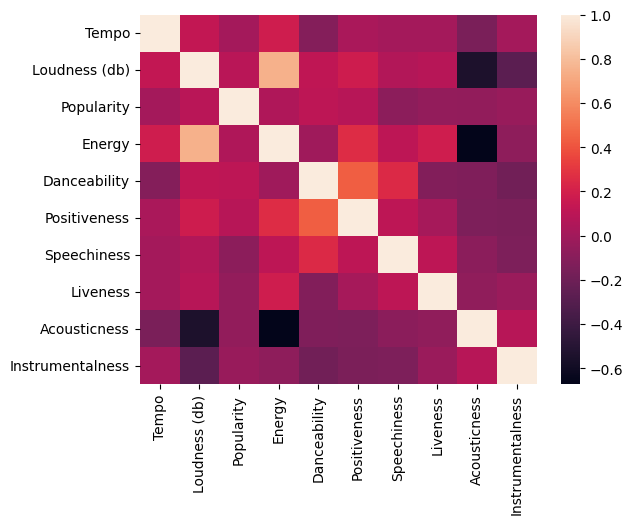

In [21]:
# print a correlation matrix only using the numeric data types in X
numeric_features = X.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_features.corr()
sns.heatmap(corr_matrix)

In [26]:
# create categorical features 
categorical_features = X.select_dtypes(include=['str'])
print(categorical_features)
print(categorical_features.dtypes)

        emotion    Key Explicit
0       sadness  minor       No
1       sadness  minor       No
2           joy  major       No
3           joy  minor       No
4           joy  minor       No
...         ...    ...      ...
551438      joy  minor      Yes
551439      joy  major       No
551440  sadness  minor       No
551441  sadness  major       No
551442     love  major       No

[551443 rows x 3 columns]
emotion     str
Key         str
Explicit    str
dtype: object


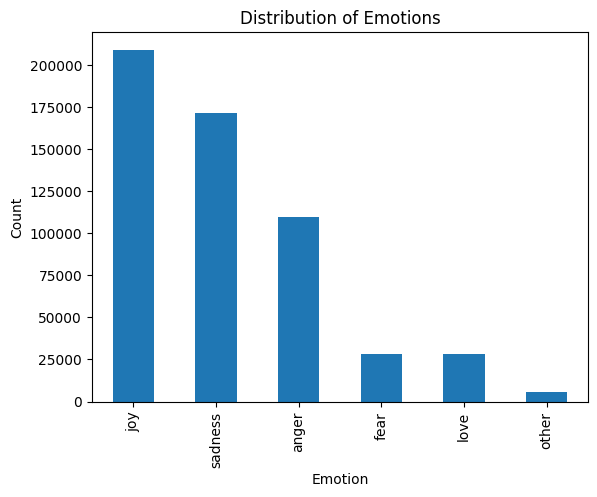

In [27]:
# see the distribution of the categorical features, start with emotion then do Key and Explicit
categorical_features['emotion'].value_counts().plot(kind='bar')
plt.title("Distribution of Emotions")
plt.ylabel("Count")
plt.xlabel("Emotion")
plt.show()

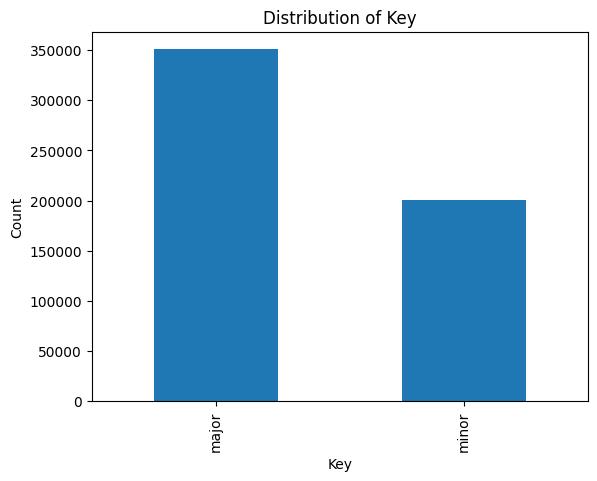

In [28]:
# Key
categorical_features['Key'].value_counts().plot(kind='bar')
plt.title("Distribution of Key")
plt.ylabel("Count")
plt.xlabel("Key")
plt.show()

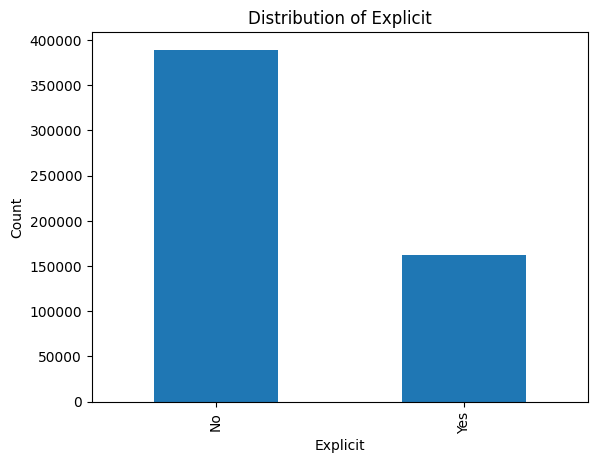

In [29]:
#Explicit
categorical_features['Explicit'].value_counts().plot(kind='bar')
plt.title("Distribution of Explicit")
plt.ylabel("Count")
plt.xlabel("Explicit")
plt.show()

We believe that the corresponding emotion and key of a song, along with if it is explicit or not plays into if a song is good for work/studying or not. Very sad songs or very happy are typically not good for studying as they divert attention away from work and are distracting. According to the National Institute of Health, very happy or sad songs engage the brain's "Default Mode Network" (DMN), leading to self-referential thought or daydreaming, rather than focused attention on external information. The key of a song determines a songs home note and scale which provides the foundational notes and chords for a piece to be composed. It determines the emotional mood of a song. Lastly, the key influences melody, harmony, chord progression, and emotional mood of a song. Whether a song is explicit or not influences if it can be used for work/studying. Songs with explicit language are not usually suitable for work/studying beucase they often require a neutral, soft, or instrumental tone so they do not distract people from focusing on what they are suppose to be working on.

Source link: https://pmc.ncbi.nlm.nih.gov/articles/PMC5663956/

# Methods & Evaluations of Models

For our project, sincd we are using binary prediction (1: yes if a song is good for work/studying or 2: no if a song is not good for work/studying), Logistic Regression, Decision Trees, and Random Forests are the models that will work best. 

## Model 1 - Logistic Regression - solver='lbfgs'

In [64]:
# make x and y
# make categorical_features and numerical_features into a list of column names not DataFrames
# add this here again to prevent error
categorical_features = X.select_dtypes(include=['str'])
categorical_features = categorical_features.columns.tolist()
# add this here again to prevent error
numeric_features = X.select_dtypes(include=['int64', 'float64'])
numeric_features = numeric_features.columns.tolist()
x = X[categorical_features + numeric_features]
y = df['Good for Work/Study']
print(X.head())
print(y.head())

   emotion    Key  Tempo  Loudness (db) Explicit  Popularity  Energy  \
0  sadness  minor    105          -6.85       No          40      83   
1  sadness  minor    117          -5.75       No          42      85   
2      joy  major    121          -6.06       No          29      89   
3      joy  minor    122          -5.42       No          24      84   
4      joy  minor    123          -5.57       No          30      71   

   Danceability  Positiveness  Speechiness  Liveness  Acousticness  \
0            71            87            4        16            11   
1            70            87            4        32             0   
2            71            63            8        64             0   
3            78            97            4        12            12   
4            77            70            7        10             4   

   Instrumentalness  
0                 0  
1                 0  
2                20  
3                 0  
4                 1  
0    0
1    0


In [65]:
# Train / test split — 80/20, stratified so class ratios are preserved 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [66]:
# prepreocessing the column transformer step
X_raw = ColumnTransformer(
    transformers=[
        ('categorical_features', OneHotEncoder(handle_unknown='ignore'), categorical_features), 
        ('numeric_features', MinMaxScaler(), numeric_features)
    ])

# create pipeline with column transformer and logistic regression model
pipeline1 = Pipeline(steps=[
    ('prep', X_raw),
    ('model', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42))
])


# fit the data into pipeline
pipeline1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_features', ...), ('numeric_features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

## Model 1 Evaluation 

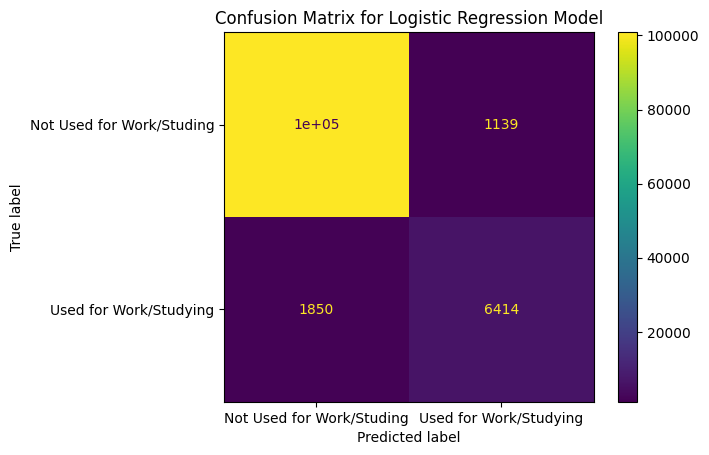

                           precision    recall  f1-score   support

Not Used for Work/Studing       0.98      0.99      0.99    102025
   Used for Work/Studying       0.85      0.78      0.81      8264

                 accuracy                           0.97    110289
                macro avg       0.92      0.88      0.90    110289
             weighted avg       0.97      0.97      0.97    110289



In [69]:
# use the pipeline to predict on the test set and then create a confusion matrix and classification report to evaluate the model performance
# predict 
y_pred_1 = pipeline1.predict(X_test)
# create confusion matrix and classification report
confusion_matrix1 = confusion_matrix(y_test, y_pred_1)
# create the display of the confusion matrix 
disp1 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix1, display_labels=['Not Used for Work/Studing', 'Used for Work/Studying'])
# plot it 
disp1.plot()
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()
#print classification report with correct target names
print(classification_report(y_test, y_pred_1, target_names=['Not Used for Work/Studing', 'Used for Work/Studying']))

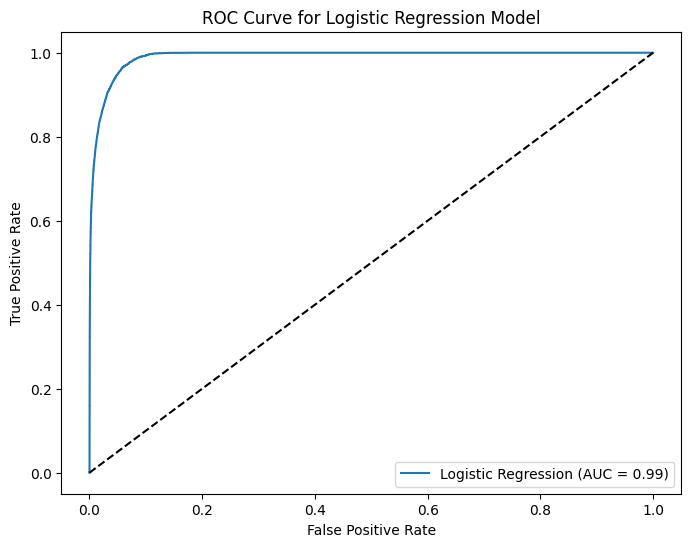

Model 1 ROC-AUC: 0.9904


In [70]:
# create a ROC curve and calculate the AUC score for the model using the pipeline to predict probabilities on the test set
fpr1, tpr1, threshold1 = roc_curve(y_test, pipeline1.predict_proba(X_test)[:, 1])
auc1 = roc_auc_score(y_test, pipeline1.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
# plot it 
plt.plot(fpr1, tpr1, label=f'Logistic Regression (AUC = {auc1:.2f})')
# plot the diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--') 
# add labels and a title and legend 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression Model')
plt.legend()
plt.show()
# print the AUC score for the model
print(f"Model 1 ROC-AUC: {auc1:.4f}")

## Model 2 - Logistic Regression - solver='saga' - class_weight='balanced'

In [71]:
# create pipeline with column transformer and logistic regression model
# use solver = 'saga' and class_weight='balanced'
pipeline2 = Pipeline(steps=[
    ('prep', X_raw),
    ('model', LogisticRegression(max_iter=1000, solver='saga', class_weight='balanced', random_state=42))
])


# fit the data into pipeline
pipeline2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_features', ...), ('numeric_features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

## Model 2 Evaluation 

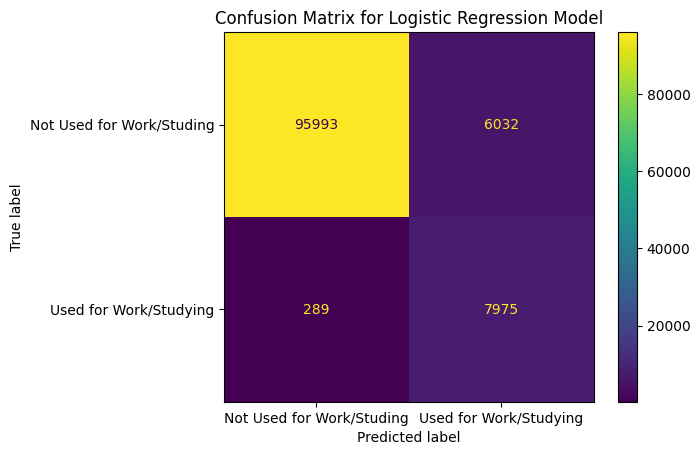

                           precision    recall  f1-score   support

Not Used for Work/Studing       1.00      0.94      0.97    102025
   Used for Work/Studying       0.57      0.97      0.72      8264

                 accuracy                           0.94    110289
                macro avg       0.78      0.95      0.84    110289
             weighted avg       0.96      0.94      0.95    110289



In [73]:
# use the pipeline to predict on the test set and then create a confusion matrix and classification report to evaluate the model performance
# predict 
y_pred_2 = pipeline2.predict(X_test)
# create confusion matrix and classification report
confusion_matrix2 = confusion_matrix(y_test, y_pred_2)
# create the display of the confusion matrix 
disp1 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix2, display_labels=['Not Used for Work/Studing', 'Used for Work/Studying'])
# plot it 
disp1.plot()
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()
#print classification report with correct target names
print(classification_report(y_test, y_pred_2, target_names=['Not Used for Work/Studing', 'Used for Work/Studying']))

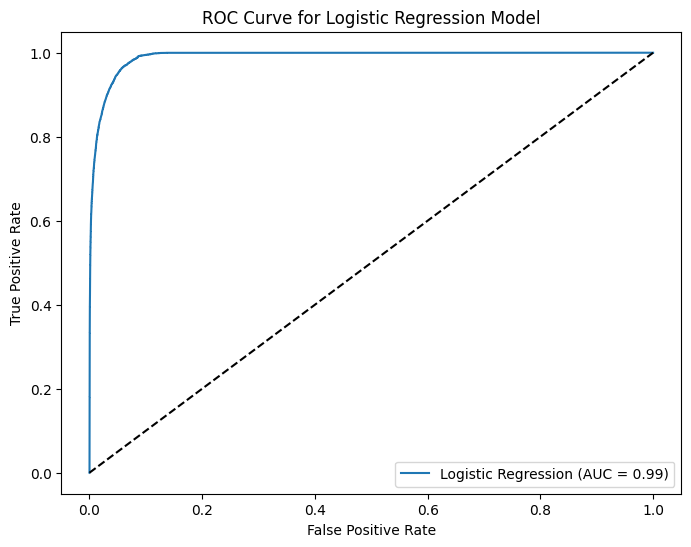

Model 2 ROC-AUC: 0.9904


In [74]:
# create a ROC curve and calculate the AUC score for the model using the pipeline to predict probabilities on the test set
fpr2, tpr2, threshold2 = roc_curve(y_test, pipeline2.predict_proba(X_test)[:, 1])
auc2 = roc_auc_score(y_test, pipeline2.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
# plot it 
plt.plot(fpr2, tpr2, label=f'Logistic Regression (AUC = {auc2:.2f})')
# plot the diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--') 
# add labels and a title and legend 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression Model')
plt.legend()
plt.show()
# print the AUC score for the model
print(f"Model 2 ROC-AUC: {auc2:.4f}")

Changing the solver to saga and adding in class_weights=balanced did not change the ROC-AUC score as it stayed at 0.9904. However, precision increased on 'Not Used for Work/Studying' from 0.98 to 1.0, but precision decreased for 'Used for Work/Studying' by 0.85 to 0.57.

## Model 3 - Decision Tree

In [75]:
# Build the pipeline – a single-step pipeline wrapping the classifier
pipe = Pipeline([
    ('classifier', DecisionTreeClassifier(random_state=1000))
])

## Model 4 - Random Forest

In [76]:
#resplit 
# Train / test split — 80/20, stratified so class ratios are preserved 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [77]:
# editthe pipeline1 for Random Forest Classifier
pipeline1 = Pipeline(steps=[
    ('prep', X_raw),
    ('model', RandomForestClassifier(random_state=42))
])

# fit the data into pipeline
pipeline1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_features', ...), ('numeric_features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

In [79]:
# new predictions  
forest_prediction = pipeline1.predict(X_test)
forest_probability = pipeline1.predict_proba(X_test)
# view the first 5 predictions of the np array
print(forest_prediction[:5])
# view the first 5 probabilities of the np array
print(forest_probability[:5])

[0 0 0 0 1]
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]]


In [80]:
# new results dataframe 
forest_results = pd.DataFrame({
    'target': y_test,
    'pred': forest_prediction,
    'prob_not_good_for_study': forest_probability[:, 0], # first column
    'prob_good_for_study': forest_probability[:, 1] # second column
})

In [81]:
# view results
forest_results.head()

,target,pred,prob_not_good_for_study,prob_good_for_study
131917,0,0,1.0,0.0
149161,0,0,1.0,0.0
393931,0,0,1.0,0.0
162847,0,0,1.0,0.0
299495,1,1,0.0,1.0


## Model 4 Evaluation

In [82]:
print(confusion_matrix(y_test, forest_prediction))


[[102019      6]
 [     0   8264]]


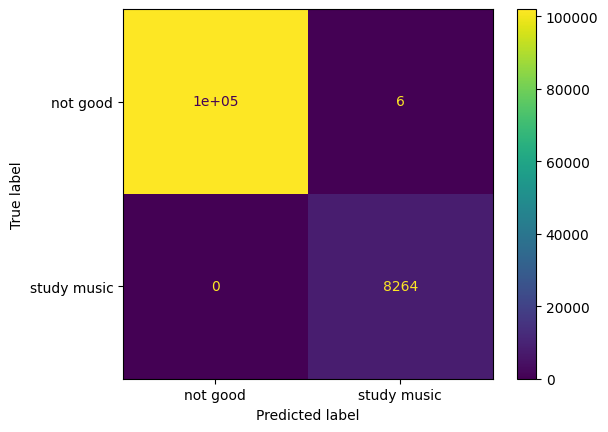

In [83]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test, forest_prediction, display_labels=['not good', 'study music'])

In [84]:
print(metrics.classification_report(y_test, forest_prediction, target_names=['not good', 'study music'])) 

              precision    recall  f1-score   support

    not good       1.00      1.00      1.00    102025
 study music       1.00      1.00      1.00      8264

    accuracy                           1.00    110289
   macro avg       1.00      1.00      1.00    110289
weighted avg       1.00      1.00      1.00    110289



# Conclusion

The best model was the Random Forest classifier. It was able to correctly predict 102,019 songs that are not good correctly. It was also able to predict 8,264 songs as good for studying correctly. It only incorrectly labeled 6 songs as study music when they were actually not good for studying. Overall, this model was the best at predicting songs as good for studying or not.

# Team Contribution

All team members - Natalie Schweickert, Mackenzie Kleczynski, and Audrey Stelle - contributed equally to this project.